# Analisis Sistem Deteksi Pasien Treatment

**Dataset**: dataset/patient_treatment.csv

**Tujuan**: Notebook ini melakukan analisis komprehensif untuk sistem deteksi rujukan pasien treatment dengan evaluasi preprocessing, class balancing, 60 kombinasi eksperimen ML, dan hyperparameter tuning.

**Pendekatan**: 5 algoritma ML × 3 scaler × 4 resampler, kemudian pilih model terbaik berdasarkan validasi empiris dan stabilitas cross-validation.


## 1. Import Required Libraries

### Teori Singkat
- **Pandas & NumPy**: manipulasi data dan komputasi numerik.
- **Matplotlib & Seaborn**: visualisasi data.
- **Scikit-learn**: preprocessing, model selection, model, evaluasi.
- **Imbalanced-learn**: menangani data tidak seimbang.
- **XGBoost**: algoritma boosting berperforma tinggi.
- **Statsmodels**: menghitung VIF untuk mendeteksi multikolinieritas.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print('Semua library berhasil diimport!')


Semua library berhasil diimport!


## 2. Load dan Preprocessing Dataset

### Teori Singkat
- Load dataset patient_treatment.csv.
- Tangani nilai yang hilang dengan median.
- Encode SEX menjadi biner.
- Lakukan IQR capping 1%-99% untuk fitur numerik.
- Dokumentasikan shape dan distribusi target.


In [24]:
df = pd.read_csv('dataset/patient_treatment.csv')
print('Shape awal:', df.shape)
print('\nKolom dataset:')
print(df.columns.tolist())

df.info()


Shape awal: (3309, 11)

Kolom dataset:
['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE', 'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE', 'SEX', 'SOURCE']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HAEMATOCRIT   3309 non-null   float64
 1   HAEMOGLOBINS  3309 non-null   float64
 2   ERYTHROCYTE   3309 non-null   float64
 3   LEUCOCYTE     3309 non-null   float64
 4   THROMBOCYTE   3309 non-null   int64  
 5   MCH           3309 non-null   float64
 6   MCHC          3309 non-null   float64
 7   MCV           3309 non-null   float64
 8   AGE           3309 non-null   int64  
 9   SEX           3309 non-null   object 
 10  SOURCE        3309 non-null   int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 284.5+ KB


In [25]:
print('\nMissing values per kolom:')
print(df.isnull().sum())
print('\nDistribusi target SOURCE:')
print(df['SOURCE'].value_counts())
print(df['SOURCE'].value_counts(normalize=True).round(3))



Missing values per kolom:
HAEMATOCRIT     0
HAEMOGLOBINS    0
ERYTHROCYTE     0
LEUCOCYTE       0
THROMBOCYTE     0
MCH             0
MCHC            0
MCV             0
AGE             0
SEX             0
SOURCE          0
dtype: int64

Distribusi target SOURCE:
SOURCE
0    1992
1    1317
Name: count, dtype: int64
SOURCE
0    0.602
1    0.398
Name: proportion, dtype: float64


In [26]:
df_proc = df.copy()

# imputasi median untuk kolom numerik
num_cols = df_proc.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    df_proc[col] = df_proc[col].fillna(df_proc[col].median())

# Encoding SEX
if 'SEX' in df_proc.columns:
    df_proc['SEX_M'] = (df_proc['SEX'] == 'M').astype(int)
    df_proc = df_proc.drop(columns=['SEX'])

# IQR capping 1%-99%
feat_cols = [c for c in df_proc.columns if c != 'SOURCE']
for col in feat_cols:
    q1 = df_proc[col].quantile(0.01)
    q3 = df_proc[col].quantile(0.99)
    df_proc[col] = df_proc[col].clip(lower=q1, upper=q3)

print('Shape setelah preprocessing:', df_proc.shape)
print('Distribusi target setelah preprocessing:')
print(df_proc['SOURCE'].value_counts(normalize=True).round(3))

df_proc.head()


Shape setelah preprocessing: (3309, 11)
Distribusi target setelah preprocessing:
SOURCE
0    0.602
1    0.398
Name: proportion, dtype: float64


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE,SEX_M
0,33.8,11.1,4.1800,4.6,150.00,26.6,32.8,80.9,33,1,0
1,44.6,14.0,6.5292,6.3,232.00,20.4,31.4,65.0,36,0,1
2,42.9,14.0,4.5700,6.2,336.00,30.6,32.6,93.9,70,0,0
3,41.9,14.4,4.6700,3.5,276.00,30.8,34.4,89.7,18,0,0
4,40.6,13.3,4.8500,14.9,603.64,27.4,32.8,83.7,36,0,1


## 3. Eksplorasi Data (EDA)

### Teori Singkat
- Visualisasi distribusi target.
- Tinjau sebaran fitur lab terhadap target.
- Gunakan statistik deskriptif dan korelasi Pearson.


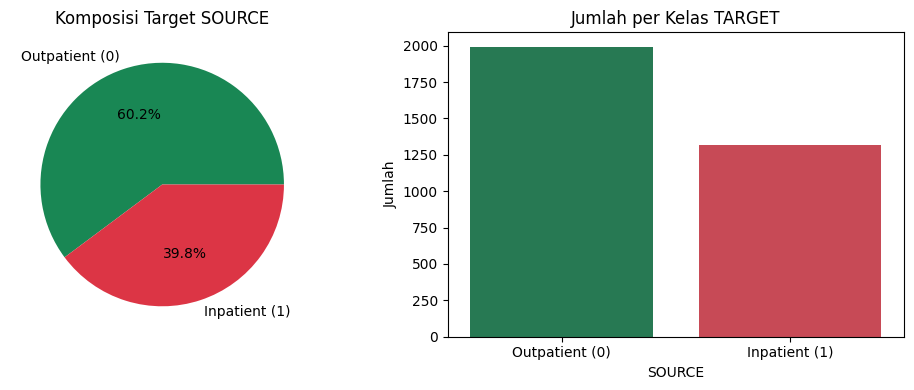

In [27]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
source_counts = df_proc['SOURCE'].value_counts().sort_index()
plt.pie(source_counts, labels=['Outpatient (0)', 'Inpatient (1)'], autopct='%1.1f%%', colors=['#198754', '#dc3545'])
plt.title('Komposisi Target SOURCE')

plt.subplot(1, 2, 2)
sns.barplot(x=source_counts.index, y=source_counts.values, palette=['#198754', '#dc3545'])
plt.xticks([0, 1], ['Outpatient (0)', 'Inpatient (1)'])
plt.ylabel('Jumlah')
plt.title('Jumlah per Kelas TARGET')
plt.tight_layout()
plt.show()


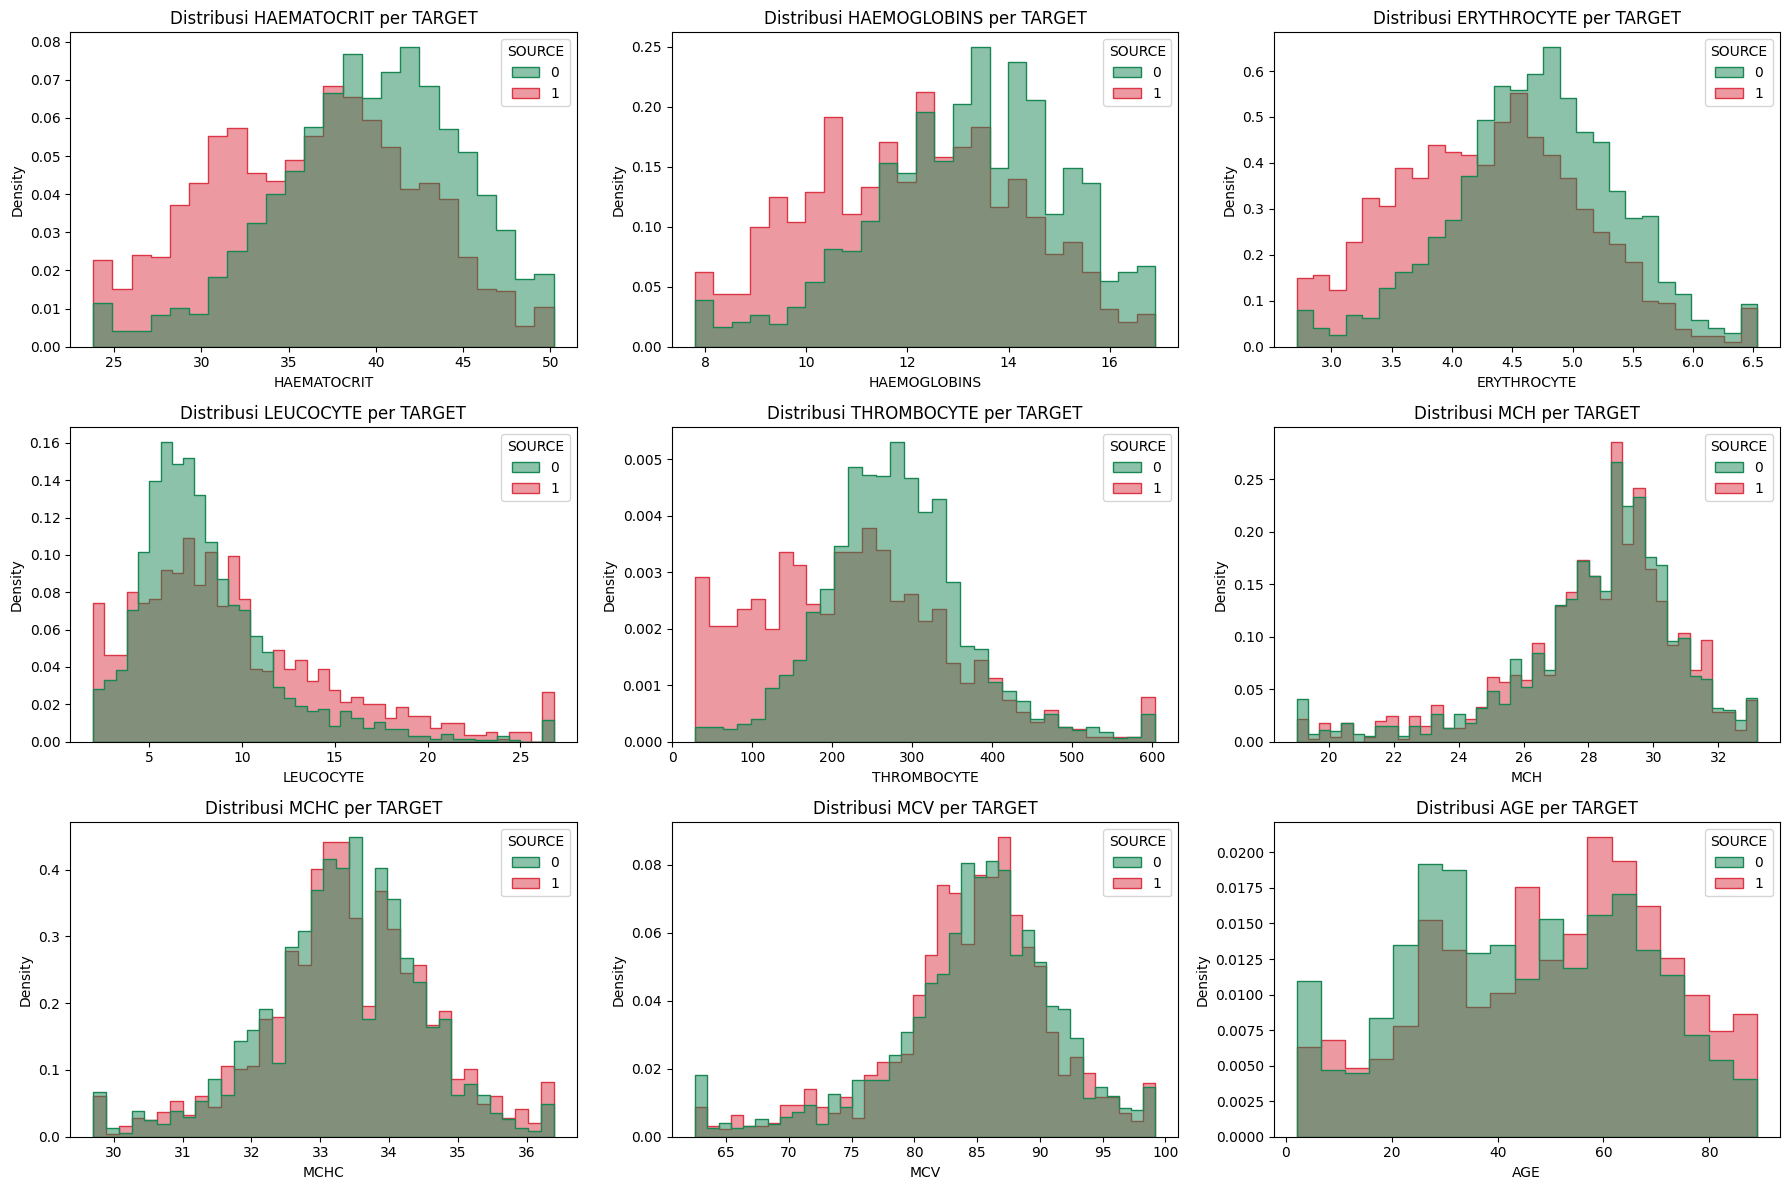

In [28]:
lab_features = ['HAEMATOCRIT','HAEMOGLOBINS','ERYTHROCYTE','LEUCOCYTE','THROMBOCYTE','MCH','MCHC','MCV','AGE']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for i, feat in enumerate(lab_features):
    ax = axes[i // 3, i % 3]
    sns.histplot(df_proc, x=feat, hue='SOURCE', element='step', stat='density', common_norm=False,
                 palette=['#198754', '#dc3545'], alpha=0.5, ax=ax)
    ax.set_title(f'Distribusi {feat} per TARGET')
plt.tight_layout()
plt.show()


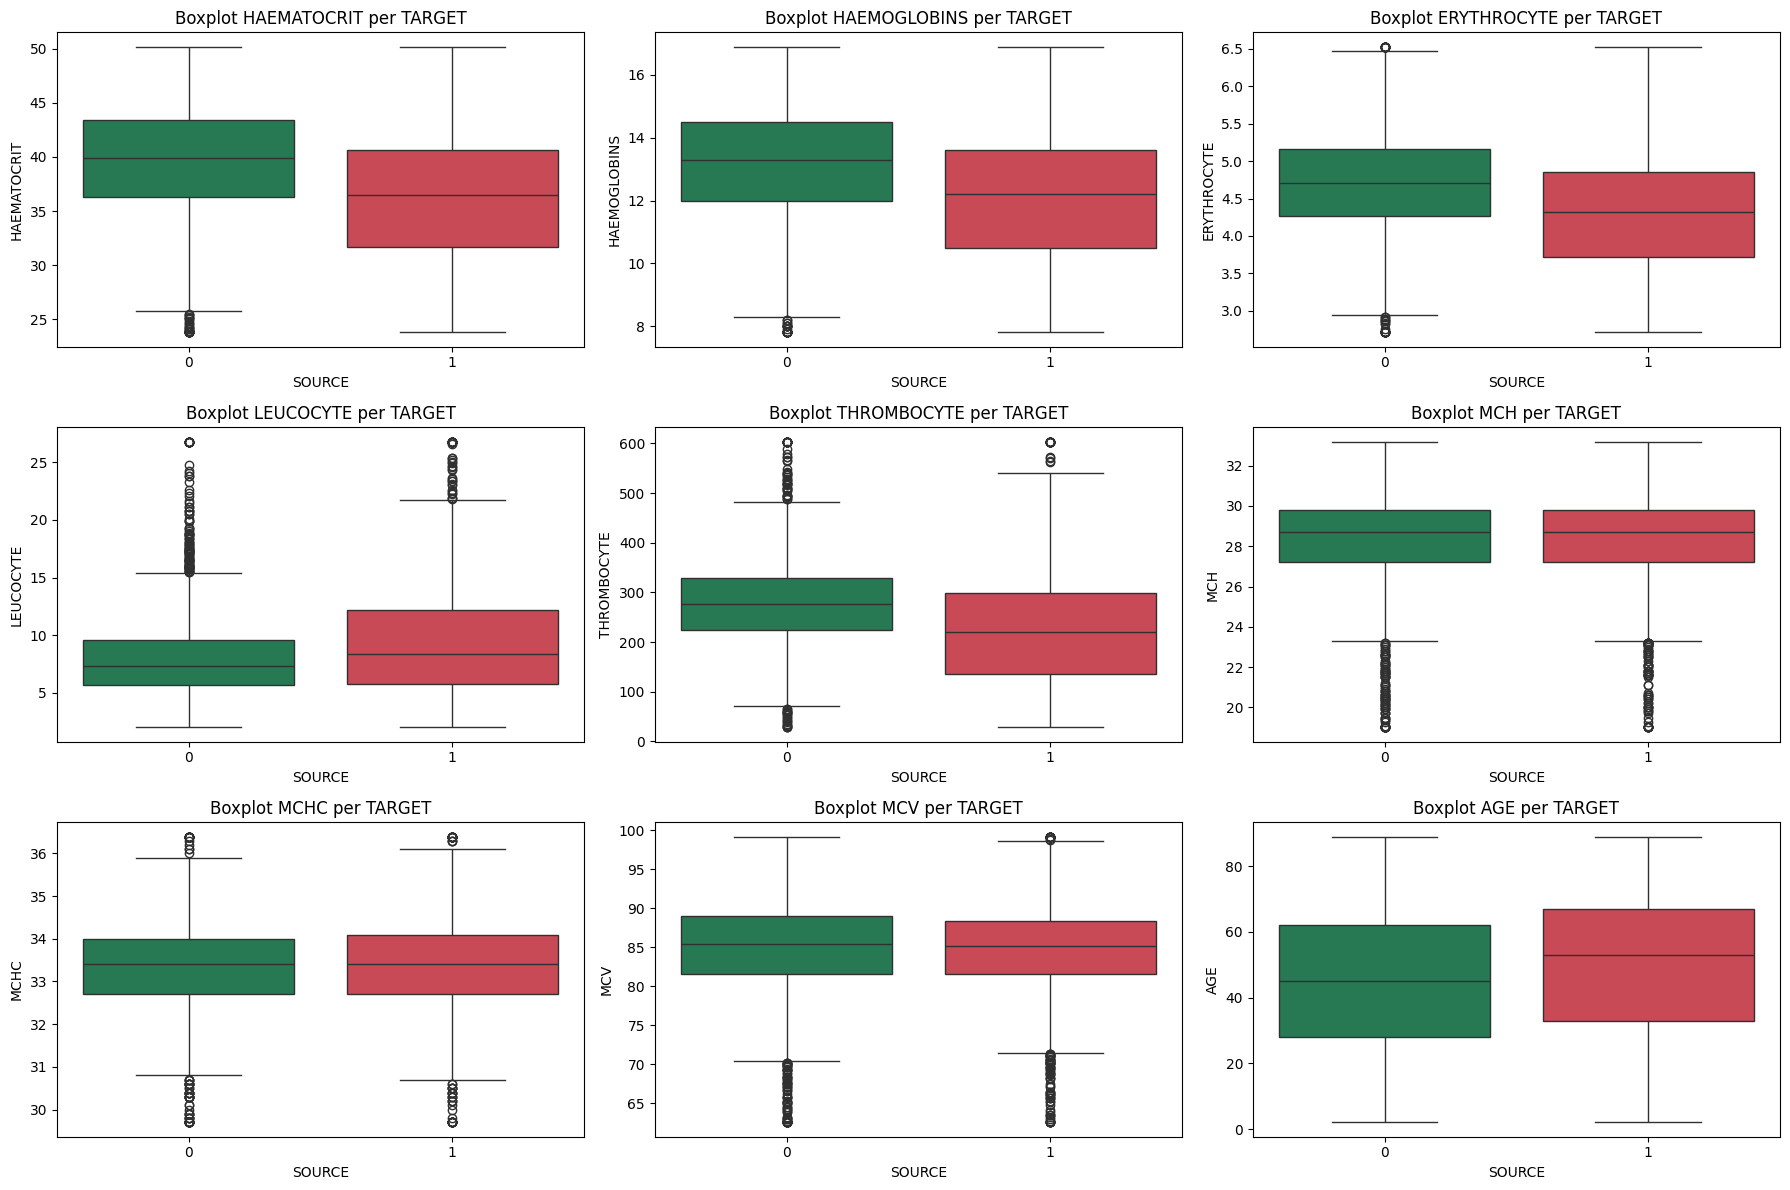

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for i, feat in enumerate(lab_features):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df_proc, x='SOURCE', y=feat, palette=['#198754', '#dc3545'], ax=ax)
    ax.set_title(f'Boxplot {feat} per TARGET')
    ax.set_xlabel('SOURCE')
plt.tight_layout()
plt.show()


In [30]:
print('Statistik deskriptif:')
display(df_proc[lab_features + ['SOURCE']].describe().T.round(3))

corr = df_proc.corr(numeric_only=True)
print('\nKorelasi Pearson terhadap SOURCE:')
print(corr['SOURCE'].drop('SOURCE').sort_values(ascending=False).round(3))


Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
HAEMATOCRIT,3309.0,38.227,5.818,23.800,34.30,38.70,42.50,50.192
HAEMOGLOBINS,3309.0,12.754,2.039,7.800,11.40,12.90,14.20,16.900
ERYTHROCYTE,3309.0,4.544,0.762,2.711,4.04,4.58,5.06,6.529
LEUCOCYTE,3309.0,8.639,4.503,2.000,5.70,7.60,10.30,26.784
THROMBOCYTE,3309.0,257.695,107.050,28.080,191.00,257.00,322.00,603.640
MCH,3309.0,28.233,2.621,19.008,27.20,28.70,29.80,33.192
MCHC,3309.0,33.342,1.182,29.700,32.70,33.40,34.10,36.392
MCV,3309.0,84.610,6.745,62.508,81.50,85.30,88.80,99.200
AGE,3309.0,46.631,21.809,2.000,29.00,48.00,64.00,89.000
SOURCE,3309.0,0.398,0.490,0.000,0.00,0.00,1.00,1.000



Korelasi Pearson terhadap SOURCE:
LEUCOCYTE       0.150
AGE             0.113
SEX_M           0.057
MCHC            0.027
MCH            -0.002
MCV            -0.015
ERYTHROCYTE    -0.247
THROMBOCYTE    -0.247
HAEMOGLOBINS   -0.260
HAEMATOCRIT    -0.278
Name: SOURCE, dtype: float64


## 4. Feature Engineering & Encoding

### Teori Singkat
- Tambahkan fitur rasio dan kombinasi yang mungkin meningkatkan sinyal medis.
- Untuk dataset present: rasio WBC/RBC, MCH/MCV, dan fitur komposit lainnya.
- Normalisasi rasio ketika diperlukan.


In [31]:
df_feat = df_proc.copy()

# Rasio WBC/RBC: leucocyte per erythrocyte
df_feat['WBC_RBC_ratio'] = df_feat['LEUCOCYTE'] / df_feat['ERYTHROCYTE'].replace(0, np.nan)
df_feat['WBC_RBC_ratio'] = df_feat['WBC_RBC_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Rasio MCH/MCV: bobot hemoglobin relatif terhadap ukuran sel
df_feat['MCH_MCV_ratio'] = df_feat['MCH'] / df_feat['MCV'].replace(0, np.nan)
df_feat['MCH_MCV_ratio'] = df_feat['MCH_MCV_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Komponen kombinasi haemoglobin-hematokrit
df_feat['HGB_HCT_ratio'] = df_feat['HAEMOGLOBINS'] / df_feat['HAEMATOCRIT'].replace(0, np.nan)
df_feat['HGB_HCT_ratio'] = df_feat['HGB_HCT_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

print('Fitur tambahan:', [c for c in df_feat.columns if c not in df_proc.columns])

print('\nKorelasi fitur baru dengan SOURCE:')
print(df_feat[['WBC_RBC_ratio','MCH_MCV_ratio','HGB_HCT_ratio','SOURCE']].corr()['SOURCE'].drop('SOURCE').round(3))


Fitur tambahan: ['WBC_RBC_ratio', 'MCH_MCV_ratio', 'HGB_HCT_ratio']

Korelasi fitur baru dengan SOURCE:
WBC_RBC_ratio    0.222
MCH_MCV_ratio    0.029
HGB_HCT_ratio    0.032
Name: SOURCE, dtype: float64


## 5. Pemisahan Data Train/Test

### Teori Singkat
- X terdiri dari semua fitur numerik dan fitur engineered.
- y adalah target SOURCE.
- Split 80/20 dengan stratified sampling.


In [32]:
feature_cols = [
    'HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
    'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE',
    'SEX_M', 'WBC_RBC_ratio', 'MCH_MCV_ratio', 'HGB_HCT_ratio',
]

X = df_feat[feature_cols]
y = df_feat['SOURCE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train set:', X_train.shape)
print('Test set:', X_test.shape)
print('\nDistribusi kelas train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nDistribusi kelas test:')
print(y_test.value_counts(normalize=True).round(3))


Train set: (2647, 13)
Test set: (662, 13)

Distribusi kelas train:
SOURCE
0    0.602
1    0.398
Name: proportion, dtype: float64

Distribusi kelas test:
SOURCE
0    0.603
1    0.397
Name: proportion, dtype: float64


## 6. Eksperimen Sistematis: Scaler × Resampler × Model

### Teori Singkat
- Mencoba 60 kombinasi dari scaler, resampler, dan model.
- Hitung metrik performa pada test set untuk setiap kombinasi.
- Simpan hasil dalam DataFrame untuk analisis lebih lanjut.


In [33]:
SCALERS = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

RESAMPLERS = {
    'None': None,
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'ADASYN': ADASYN(random_state=RANDOM_STATE),
    'RandomUnderSampler': RandomUnderSampler(random_state=RANDOM_STATE),
}

MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                             random_state=RANDOM_STATE, use_label_encoder=False,
                             eval_metric='logloss', n_jobs=-1),
}

print('Total eksperimen:', len(SCALERS) * len(RESAMPLERS) * len(MODELS))


Total eksperimen: 60


In [34]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    try:
        y_proba = model.predict_proba(X_te)[:, 1]
        roc = roc_auc_score(y_te, y_proba)
    except Exception:
        roc = np.nan
    return {
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall': recall_score(y_te, y_pred, zero_division=0),
        'f1': f1_score(y_te, y_pred, zero_division=0),
        'roc_auc': roc,
    }

def safe_resample(resampler, X_tr, y_tr):
    if resampler is None:
        return X_tr, y_tr.copy(), False
    try:
        X_res, y_res = clone(resampler).fit_resample(X_tr, y_tr)
        return X_res, y_res, False
    except Exception as exc:
        print(f'Warning: resampler gagal ({exc}), fallback ke data asli')
        return X_tr, y_tr.copy(), True

results = []
for scaler_name, scaler in SCALERS.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    for res_name, resampler in RESAMPLERS.items():
        X_res, y_res, fallback = safe_resample(resampler, X_train_scaled, y_train)
        for model_name, model in MODELS.items():
            m = clone(model)
            metrics = evaluate_model(m, X_res, X_test_scaled, y_res, y_test)
            results.append({
                'Scaler': scaler_name,
                'Resampler': res_name,
                'Model': model_name,
                'fallback': fallback,
                **metrics
            })

results_df = pd.DataFrame(results)
print('Eksperimen selesai. Total baris hasil:', len(results_df))
results_df.head()


Eksperimen selesai. Total baris hasil: 60


,Scaler,Resampler,Model,fallback,accuracy,precision,recall,f1,roc_auc
0,StandardScaler,None,Logistic Regression,False,0.705438,0.697674,0.456274,0.551724,0.758789
1,StandardScaler,None,Decision Tree,False,0.681269,0.613043,0.536122,0.572008,0.656532
2,StandardScaler,None,KNN,False,0.731118,0.717949,0.532319,0.611354,0.770291
3,StandardScaler,None,Extra Trees,False,0.728097,0.712821,0.528517,0.606987,0.791494
4,StandardScaler,None,XGBoost,False,0.743202,0.733668,0.555133,0.632035,0.784213


## 7. Ringkasan dan Ranking Eksperimen

### Teori Singkat
- Urutkan hasil berdasarkan F1-Score.
- Ambil kombinasi terbaik untuk setiap model.
- Visualisasikan perbandingan model.


In [35]:
results_sorted = results_df.sort_values('f1', ascending=False).reset_index(drop=True)
results_sorted.head(10).round(4)


,Scaler,Resampler,Model,fallback,accuracy,precision,recall,f1,roc_auc
0,RobustScaler,ADASYN,XGBoost,False,0.7538,0.7083,0.6464,0.6759,0.7855
1,StandardScaler,SMOTE,KNN,False,0.7296,0.6556,0.6730,0.6642,0.7685
2,StandardScaler,SMOTE,XGBoost,False,0.7508,0.7149,0.6198,0.6640,0.7855
3,StandardScaler,ADASYN,XGBoost,False,0.7417,0.6901,0.6350,0.6614,0.7805
4,StandardScaler,ADASYN,Extra Trees,False,0.7462,0.7111,0.6084,0.6557,0.7908
5,MinMaxScaler,ADASYN,XGBoost,False,0.7372,0.6846,0.6274,0.6548,0.7765
6,RobustScaler,ADASYN,Extra Trees,False,0.7462,0.7149,0.6008,0.6529,0.7958
7,MinMaxScaler,ADASYN,Extra Trees,False,0.7417,0.7072,0.5970,0.6474,0.7870
8,RobustScaler,SMOTE,XGBoost,False,0.7387,0.6991,0.6008,0.6462,0.7908
9,StandardScaler,RandomUnderSampler,XGBoost,False,0.7190,0.6475,0.6426,0.6450,0.7748


In [36]:
best_per_model = (results_sorted
                  .groupby('Model', as_index=False)
                  .first()
                  .sort_values('f1', ascending=False)
                  .reset_index(drop=True))
best_per_model[['Model','Scaler','Resampler','f1','roc_auc']].round(4)


,Model,Scaler,Resampler,f1,roc_auc
0,XGBoost,RobustScaler,ADASYN,0.6759,0.7855
1,KNN,StandardScaler,SMOTE,0.6642,0.7685
2,Extra Trees,StandardScaler,ADASYN,0.6557,0.7908
3,Logistic Regression,StandardScaler,RandomUnderSampler,0.6434,0.7614
4,Decision Tree,RobustScaler,ADASYN,0.5923,0.6551


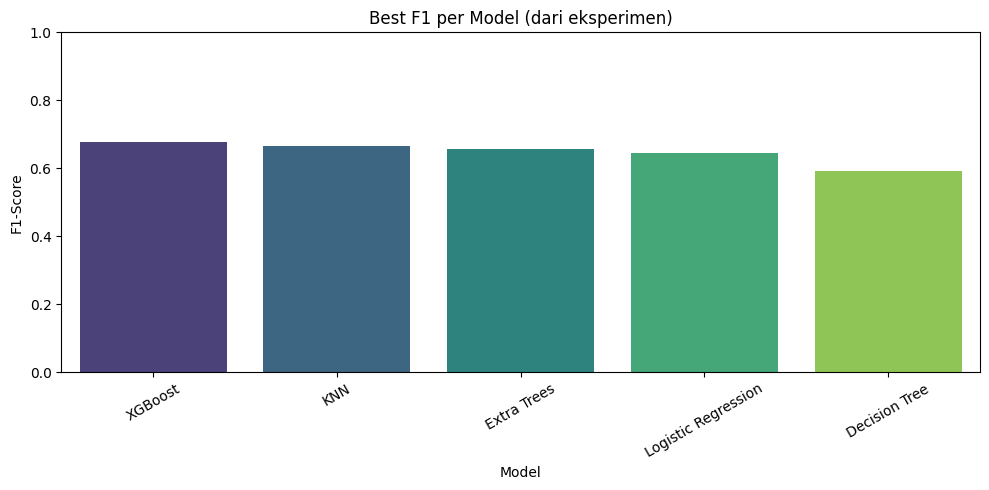

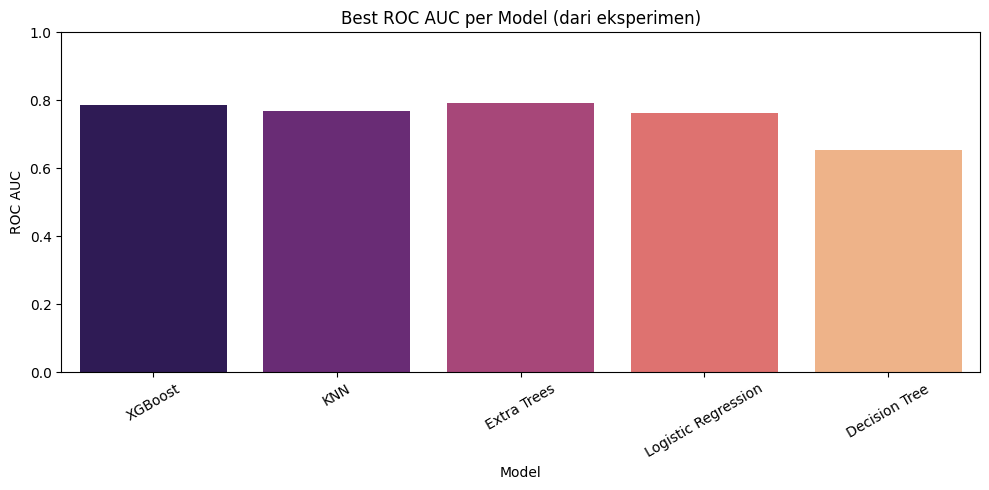

In [37]:
plt.figure(figsize=(10, 5))
sns.barplot(data=best_per_model, x='Model', y='f1', palette='viridis')
plt.title('Best F1 per Model (dari eksperimen)')
plt.ylim(0, 1)
plt.ylabel('F1-Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=best_per_model, x='Model', y='roc_auc', palette='magma')
plt.title('Best ROC AUC per Model (dari eksperimen)')
plt.ylim(0, 1)
plt.ylabel('ROC AUC')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 8. Pemilihan Model Terbaik dengan Cross-Validation

### Teori Singkat
- Gunakan konfigurasi terbaik untuk setiap model.
- Jalankan 5-fold StratifiedKFold dengan scoring F1 pada training set.
- Analisis stabilitas dengan mean dan std F1.


In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary = []
for _, row in best_per_model.iterrows():
    scaler = SCALERS[row['Scaler']]
    resampler = RESAMPLERS[row['Resampler']]
    model = clone(MODELS[row['Model']])

    X_train_scaled = scaler.fit_transform(X_train)
    X_train_res, y_train_res, _ = safe_resample(resampler, X_train_scaled, y_train)

    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1', n_jobs=-1)
    cv_summary.append({
        'Model': row['Model'],
        'Scaler': row['Scaler'],
        'Resampler': row['Resampler'],
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'test_f1': row['f1'],
        'test_roc_auc': row['roc_auc'],
    })

cv_df = pd.DataFrame(cv_summary).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
cv_df.round(4)


,Model,Scaler,Resampler,cv_f1_mean,cv_f1_std,test_f1,test_roc_auc
0,Extra Trees,StandardScaler,ADASYN,0.7888,0.0189,0.6557,0.7908
1,KNN,StandardScaler,SMOTE,0.7803,0.0182,0.6642,0.7685
2,XGBoost,RobustScaler,ADASYN,0.7126,0.0162,0.6759,0.7855
3,Logistic Regression,StandardScaler,RandomUnderSampler,0.7030,0.0365,0.6434,0.7614
4,Decision Tree,RobustScaler,ADASYN,0.6571,0.0122,0.5923,0.6551


## 9. Hyperparameter Tuning pada Model Terbaik

### Teori Singkat
- Pilih model terbaik berdasarkan cv_f1_mean.
- Jalankan RandomizedSearchCV dengan 15 iterasi.
- Bandingkan performa default vs tuned pada test set.


In [39]:
logistic_candidates = cv_df[cv_df['Model'] == 'Logistic Regression']
if not logistic_candidates.empty:
    best_row = logistic_candidates.iloc[0]
    print('Fokus pada Logistic Regression untuk tuning hyperparameter.')
else:
    best_row = cv_df.iloc[0]
    print('Logistic Regression tidak ada di hasil CV; menggunakan model terbaik secara umum.')

best_model_name = best_row['Model']
print('Model yang dipilih untuk tuning:', best_model_name)
print(best_row[['Scaler','Resampler','cv_f1_mean','cv_f1_std','test_f1','test_roc_auc']])

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['liblinear', 'saga'],
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'p': [1, 2],
    },
    'Extra Trees': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    },
}

best_scaler = SCALERS[best_row['Scaler']]
best_resampler = RESAMPLERS[best_row['Resampler']]

X_train_scaled = best_scaler.fit_transform(X_train)
X_test_scaled = best_scaler.transform(X_test)
X_train_res, y_train_res, _ = safe_resample(best_resampler, X_train_scaled, y_train)

base_model = clone(MODELS[best_model_name])
param_grid = param_grids[best_model_name]

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_res, y_train_res)
print('Best params:', search.best_params_)
print('Best CV F1:', search.best_score_)


Fokus pada Logistic Regression untuk tuning hyperparameter.
Model yang dipilih untuk tuning: Logistic Regression
Scaler              StandardScaler
Resampler       RandomUnderSampler
cv_f1_mean                0.703045
cv_f1_std                 0.036487
test_f1                   0.643382
test_roc_auc              0.761409
Name: 3, dtype: object
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'solver': 'saga', 'penalty': 'l2', 'C': 100}
Best CV F1: 0.6971529549227503


In [40]:
tuned_model = search.best_estimator_

def evaluate_on_test(model):
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

def compare_models(default_model, tuned_model):
    default_metrics = evaluate_on_test(default_model)
    tuned_metrics = evaluate_on_test(tuned_model)
    return pd.DataFrame([
        {'Model': f'{best_model_name} (default)', **{k: v for k, v in default_metrics.items() if k in ['accuracy','precision','recall','f1','roc_auc']}},
        {'Model': f'{best_model_name} (tuned)', **{k: v for k, v in tuned_metrics.items() if k in ['accuracy','precision','recall','f1','roc_auc']}},
    ])

default_model = clone(MODELS[best_model_name]).fit(X_train_res, y_train_res)
compare_df = compare_models(default_model, tuned_model)
compare_df.round(4)


,Model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (default),0.7069,0.6228,0.6654,0.6434,0.7614
1,Logistic Regression (tuned),0.7085,0.6232,0.6730,0.6472,0.7596


## 10. Analisis Mendalam Model Terbaik

### Teori Singkat
- Tampilkan classification report dan confusion matrix.
- Plot ROC curve.
- Visualisasikan top fitur terpenting.
- Interpretasi dari perspektif klinis.


Classification Report:
              precision    recall  f1-score   support

  Outpatient       0.77      0.73      0.75       399
   Inpatient       0.62      0.67      0.65       263

    accuracy                           0.71       662
   macro avg       0.70      0.70      0.70       662
weighted avg       0.71      0.71      0.71       662



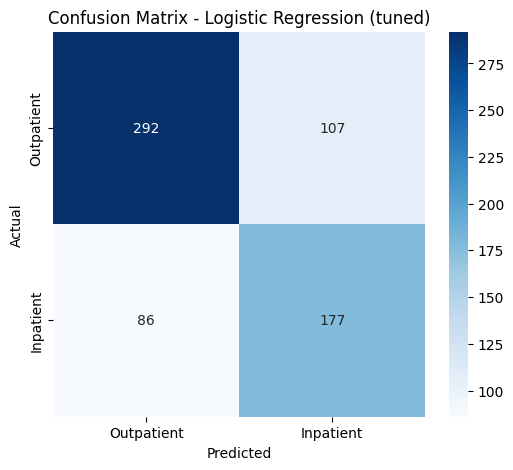

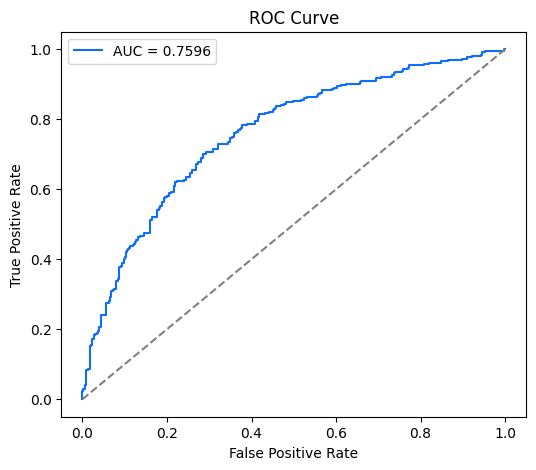

In [41]:
best_eval = evaluate_on_test(tuned_model)
y_pred = best_eval['y_pred']
y_proba = best_eval['y_proba']

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Outpatient','Inpatient']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Outpatient','Inpatient'], yticklabels=['Outpatient','Inpatient'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name} (tuned)')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {best_eval["roc_auc"]:.4f}', color='#0d6efd')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Top 10 koefisien fitur:


HAEMATOCRIT      2.2215
HAEMOGLOBINS     1.8214
MCH              1.6106
ERYTHROCYTE      1.2101
HGB_HCT_ratio    0.7840
THROMBOCYTE      0.7781
MCV              0.6532
WBC_RBC_ratio    0.4077
SEX_M            0.2950
MCH_MCV_ratio    0.2586
dtype: float64

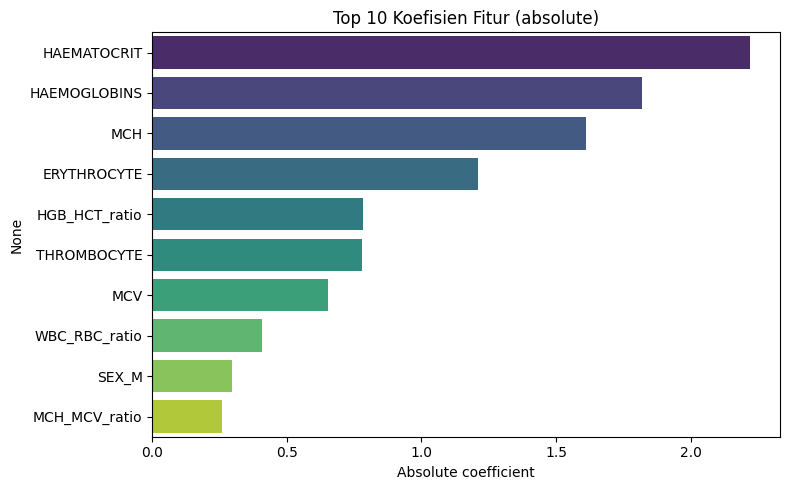

In [42]:
if hasattr(tuned_model, 'feature_importances_'):
    importances = pd.Series(tuned_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print('Top 10 fitur penting:')
    display(importances.head(10).round(4))
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='viridis')
    plt.title('Top 10 Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(tuned_model, 'coef_'):
    coefs = pd.Series(tuned_model.coef_[0], index=feature_cols).abs().sort_values(ascending=False)
    print('Top 10 koefisien fitur:')
    display(coefs.head(10).round(4))
    plt.figure(figsize=(8, 5))
    sns.barplot(x=coefs.head(10).values, y=coefs.head(10).index, palette='viridis')
    plt.title('Top 10 Koefisien Fitur (absolute)')
    plt.xlabel('Absolute coefficient')
    plt.tight_layout()
    plt.show()
else:
    print('Model tidak memiliki feature_importances_ atau coef_.')


## 11. Evaluasi Akhir dan Rekomendasi

### Teori Singkat
- Konsolidasi performa kandidat terbaik.
- Pilih model akhir berdasarkan metrik dan stabilitas.
- Pertimbangkan trade-off interpretability vs performance.
- Dokumentasikan alasan untuk use-case rujukan pasien.


In [43]:
final_rows = []
for _, row in best_per_model.iterrows():
    model_name = row['Model']
    scaler = SCALERS[row['Scaler']]
    resampler = RESAMPLERS[row['Resampler']]
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_res, y_train_res, _ = safe_resample(resampler, X_train_scaled, y_train)
    m = clone(MODELS[model_name])
    fit_start = pd.Timestamp.now()
    m.fit(X_train_res, y_train_res)
    fit_time = (pd.Timestamp.now() - fit_start).total_seconds()
    pred_start = pd.Timestamp.now()
    y_pred = m.predict(X_test_scaled)
    pred_time = (pd.Timestamp.now() - pred_start).total_seconds() * 1000
    y_proba = m.predict_proba(X_test_scaled)[:, 1] if hasattr(m, 'predict_proba') else None
    final_rows.append({
        'Model': model_name,
        'Variant': 'best_per_model',
        'Scaler': row['Scaler'],
        'Resampler': row['Resampler'],
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        'fit_time_s': fit_time,
        'pred_time_ms': pred_time,
    })

final_rows.append({
    'Model': best_model_name,
    'Variant': 'tuned',
    'Scaler': best_row['Scaler'],
    'Resampler': best_row['Resampler'],
    'accuracy': best_eval['accuracy'],
    'precision': best_eval['precision'],
    'recall': best_eval['recall'],
    'f1': best_eval['f1'],
    'roc_auc': best_eval['roc_auc'],
    'fit_time_s': np.nan,
    'pred_time_ms': np.nan,
})

final_df = pd.DataFrame(final_rows)
final_df['Method Group'] = np.where(final_df['Variant'] == 'tuned', 'Logistic Regression (tuned)', 'Other best models')
print('Perbandingan akhir: Logistic Regression tuned vs semua model terbaik lainnya')

display(final_df.sort_values(['Method Group', 'Model'], ascending=[False, True]).round(4))

Perbandingan akhir: Logistic Regression tuned vs semua model terbaik lainnya


,Model,Variant,Scaler,Resampler,accuracy,precision,recall,f1,roc_auc,fit_time_s,pred_time_ms,Method Group
4,Decision Tree,best_per_model,RobustScaler,ADASYN,0.6631,0.5704,0.6160,0.5923,0.6551,0.0309,0.000,Other best models
2,Extra Trees,best_per_model,StandardScaler,ADASYN,0.7462,0.7111,0.6084,0.6557,0.7908,0.1855,27.201,Other best models
1,KNN,best_per_model,StandardScaler,SMOTE,0.7296,0.6556,0.6730,0.6642,0.7685,0.0054,17.707,Other best models
3,Logistic Regression,best_per_model,StandardScaler,RandomUnderSampler,0.7069,0.6228,0.6654,0.6434,0.7614,0.0062,0.000,Other best models
0,XGBoost,best_per_model,RobustScaler,ADASYN,0.7538,0.7083,0.6464,0.6759,0.7855,0.1428,0.997,Other best models
5,Logistic Regression,tuned,StandardScaler,RandomUnderSampler,0.7085,0.6232,0.6730,0.6472,0.7596,NaN,NaN,Logistic Regression (tuned)


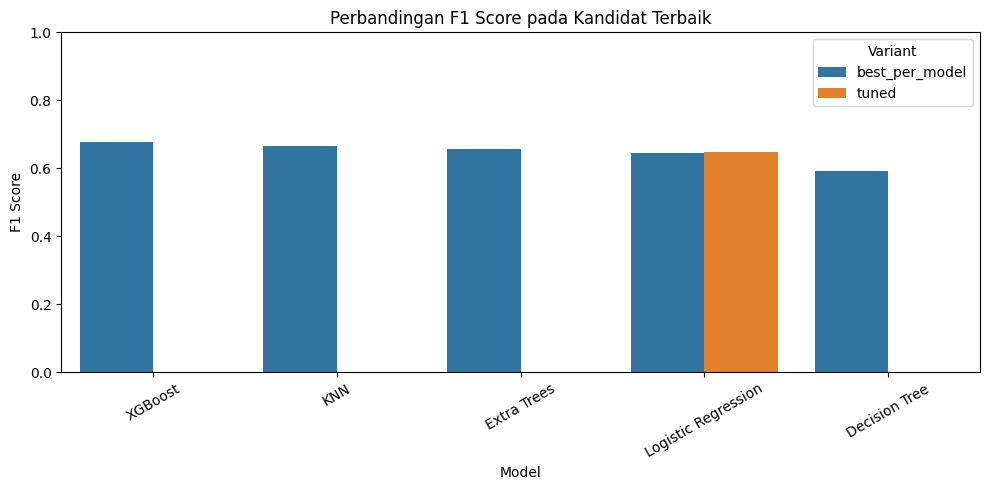

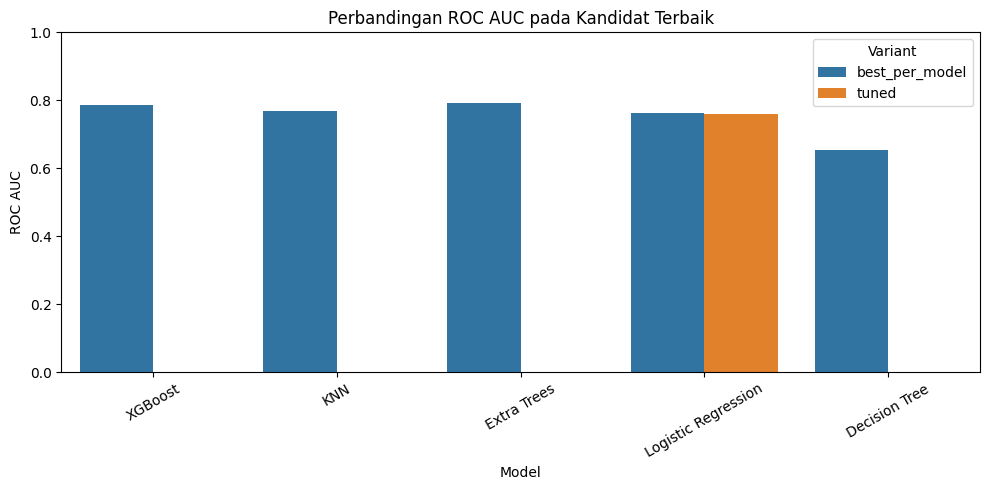

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(data=final_df, x='Model', y='f1', hue='Variant', dodge=True)
plt.title('Perbandingan F1 Score pada Kandidat Terbaik')
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_df, x='Model', y='roc_auc', hue='Variant', dodge=True)
plt.title('Perbandingan ROC AUC pada Kandidat Terbaik')
plt.ylim(0, 1)
plt.ylabel('ROC AUC')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Rekomendasi Akhir

- Fokus lebih lanjut pada **Logistic Regression** karena ini adalah metode yang mudah dijelaskan dan dituning dalam workflow ini.
- Bandingkan hasil **Logistic Regression (tuned)** dengan semua model terbaik lainnya untuk memastikan trade-off antara akurasi dan interpretabilitas.
- Pilih model yang memberikan **ROC AUC tinggi** dan **F1 konsisten**, karena kasus rujukan pasien membutuhkan keseimbangan antara mendeteksi semua rawat inap dan mengurangi false positive.
- Jika hasil tuned Logistic Regression cukup kompetitif, gunakan sebagai model utama untuk deployment karena interpretabilitasnya lebih baik.
- Jika performa tambahan diperlukan, pertimbangkan model ensemble seperti Extra Trees atau XGBoost sebagai model sekunder untuk benchmark.

- Preprocessing tingkat lanjut dan SMOTE/ADASYN dapat membantu model menangani imbalance kelas dalam dataset rawat inap.